In [1]:
## Notebook for downloading SWOT L3 version 3 data
## created on April 22, 2026
## Anup Nambiathody


In [ ]:
## Before downloading make sure you have AVISO+ credentials
#If you are not registered please follow the link to register
# (https://www.aviso.altimetry.fr/en/data/data-access/registration-form.html).

## Make sure you know the pass numbers of the SWOT 
## This code downloads the SWOT data pass number 270 and plots the mean sea surface for the entire pass

In [2]:
from getpass import getpass
import os
import ftplib


In [3]:
## this is the fucntion to download SWOT data.
def download_sowt(
    ftp_path,
    level,
    variant,
    passes,
    output_dir,
    cycle_numbers=None,     
    cycle_range=None,       
    only_last=True
):
    ftp_host = "ftp-access.aviso.altimetry.fr"
    os.makedirs(output_dir, exist_ok=True)

    with ftplib.FTP(ftp_host) as ftp:
        ftp.login(username, password)
        ftp.cwd(ftp_path)
        print("Connected:", ftp.getwelcome())

        # ---- DETECT AVAILABLE CYCLES ----
        all_dirs = ftp.nlst()
        available_cycles = sorted([
            int(d.split("_")[1])
            for d in all_dirs if d.startswith("cycle_")
        ])

        # ---- SELECT CYCLES ----
        if cycle_numbers == "all":
            selected_cycles = available_cycles

        elif cycle_range is not None:
            start, end = cycle_range
            selected_cycles = [c for c in available_cycles if start <= c <= end]

        elif cycle_numbers is not None:
            selected_cycles = cycle_numbers

        else:
            raise ValueError("Provide cycle_numbers, cycle_range, or 'all'")

        print(f"cycle numbers: {selected_cycles}")

        downloaded_files = []

        for cycle in selected_cycles:
            cycle_str = f"{cycle:03d}"
            cycle_dir = f"cycle_{cycle_str}"

            try:
                ftp.cwd(cycle_dir)
            except:
                print(f"Skipping {cycle_dir}")
                continue

            print(f"\nCycle {cycle_str}")
            files = ftp.nlst()

            for p in passes:
                pass_str = f"{p:03d}"

                matched = [
                    f for f in files
                    if f.startswith(f"SWOT_{level}_LR_SSH_{variant}_{cycle_str}_{pass_str}")
                    and f.endswith(".nc")
                ]

                if not matched:
                    print(f"No pass {pass_str}")
                    continue

                for fname in matched:
                    local_path = os.path.join(output_dir, fname)

                    if os.path.exists(local_path):
                        print(f"Skip {fname}")
                        continue

                    print(f"Downloading {fname}")
                    with open(local_path, "wb") as f:
                        ftp.retrbinary(f"RETR {fname}", f.write)

                    downloaded_files.append(local_path)

            ftp.cwd("..")

        ftp.quit()
        return downloaded_files

In [4]:
# AVISO login credentials
## input user name and password
username = input("Enter FTP username: ")
password = getpass("Enter FTP password: ")

In [5]:
# the path where nc files are stored. you have freedom to change this depending the which version you wish to use
## This path takes you to 2km v3 Expert product.

ftp_path = '/swot_products/l3_karin_nadir/l3_lr_ssh/v3_0/Expert/reproc/'

files = download_sowt(
    ftp_path=ftp_path,
    level="L3",
    variant="Expert",  # "Basic" "Expert" "Technical". Remember to change the ftp path if you make changes here
    passes=[270],  ## specify the pass number
    cycle_numbers=[1], # cycle_numbers="all" for all cycles
    output_dir="./data" ## the path to download files
)

Connected: 220 192.168.10.119 FTP server ready
cycle numbers: [1]

Cycle 001


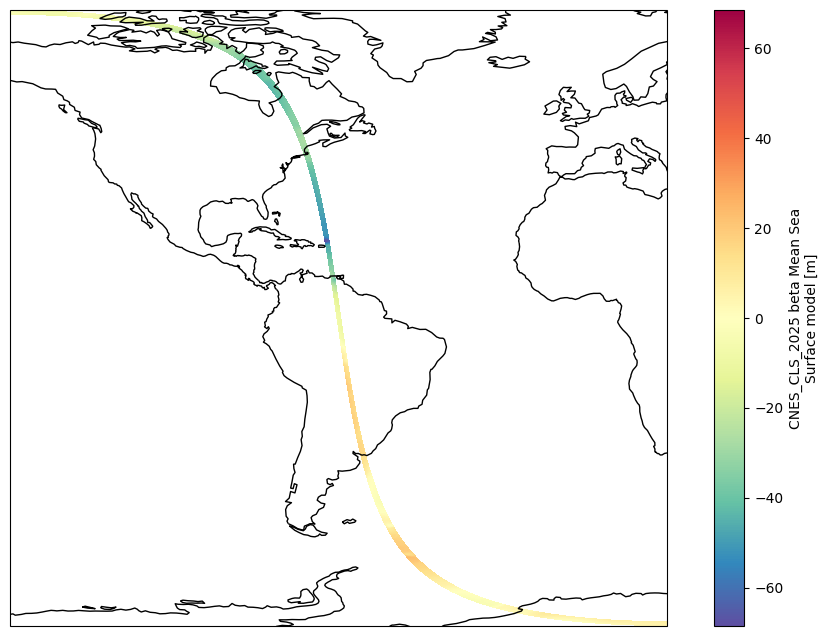

In [6]:
## visualise the downloaded path

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

ds = xr.open_dataset("data/SWOT_L3_LR_SSH_Expert_001_270_20230730T201302_20230730T210429_v3.0.nc")
fig, ax = plt.subplots( figsize=(12, 8),
                               subplot_kw=dict(projection=ccrs.PlateCarree()))
ds['mss'].plot.pcolormesh(
            ax=ax,
     x="longitude",
        y="latitude",
        cmap="Spectral_r",
#         vmin=-0.25,
#         vmax=0.25,
)
ax.coastlines()
# ax.set_extent([-8, 12, 48, 62])
plt.show()